In [1]:
import matplotlib.pyplot as plt

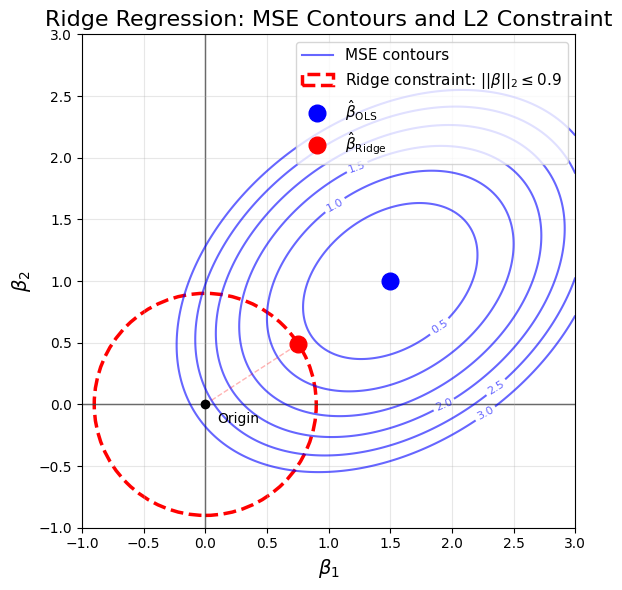

OLS estimate: β₁=1.500, β₂=1.000
Ridge estimate: β₁=0.755, β₂=0.490
Ridge constraint satisfied: ||β_ridge||₂ = 0.900 ≈ 0.9


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Set up the figure
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Define the true OLS solution (ERM estimate)
beta_ols = np.array([1.5, 1.0])

# Define the covariance matrix for the MSE ellipses
# This controls the shape of the MSE contours
cov_matrix = np.array([[1.0, 0.3],
                       [0.3, 0.8]])
cov_inv = np.linalg.inv(cov_matrix)

# Create a grid for plotting contours
beta1_range = np.linspace(-1, 3, 200)
beta2_range = np.linspace(-1, 3, 200)
Beta1, Beta2 = np.meshgrid(beta1_range, beta2_range)

# Calculate MSE values for the grid (quadratic form)
# MSE = (beta - beta_ols)^T * cov_inv * (beta - beta_ols)
MSE = np.zeros_like(Beta1)
for i in range(Beta1.shape[0]):
    for j in range(Beta1.shape[1]):
        beta = np.array([Beta1[i, j], Beta2[i, j]])
        diff = beta - beta_ols
        MSE[i, j] = diff @ cov_inv @ diff

# Plot MSE contours (limited to 3.0)
contour_levels = [0.5, 1, 1.5, 2, 2.5, 3]
contours = ax.contour(Beta1, Beta2, MSE, levels=contour_levels, colors='blue', alpha=0.6, linewidths=1.5)
ax.clabel(contours, inline=True, fontsize=8, fmt='%.1f')

# Add a dummy line for the legend to represent MSE contours
ax.plot([], [], 'b-', alpha=0.6, linewidth=1.5, label='MSE contours')

# Ridge constraint radius
ridge_radius = 0.9

# Plot the ridge constraint circle
circle = Circle((0, 0), ridge_radius, fill=False, edgecolor='red', linewidth=2.5,
                linestyle='--', label=f'Ridge constraint: $||\\beta||_2 \leq {ridge_radius}$')
ax.add_patch(circle)

# Find the ridge solution (approximately where the smallest contour touches the circle)
# This is done by finding the point on the constraint boundary that minimizes MSE
# Using Lagrange multipliers, the solution is: beta_ridge = (cov_inv + lambda*I)^(-1) * cov_inv * beta_ols
# We'll find lambda such that ||beta_ridge|| = ridge_radius

from scipy.optimize import minimize_scalar

def get_beta_ridge(lam):
    ridge_matrix = cov_inv + lam * np.eye(2)
    beta_ridge = np.linalg.inv(ridge_matrix) @ cov_inv @ beta_ols
    return beta_ridge

def constraint_violation(lam):
    beta_ridge = get_beta_ridge(lam)
    return (np.linalg.norm(beta_ridge) - ridge_radius)**2

# Find the optimal lambda
result = minimize_scalar(constraint_violation, bounds=(0, 10), method='bounded')
optimal_lambda = result.x
beta_ridge = get_beta_ridge(optimal_lambda)

# Add darker axis lines at origin
ax.axhline(y=0, color='black', linewidth=1, alpha=0.7, zorder=1)
ax.axvline(x=0, color='black', linewidth=1, alpha=0.7, zorder=1)

# Plot the OLS (ERM) solution
ax.plot(beta_ols[0], beta_ols[1], 'bo', markersize=12, label=r'$\hat \beta_\mathrm{OLS}$', zorder=5)

# Plot the ridge solution
ax.plot(beta_ridge[0], beta_ridge[1], 'ro', markersize=12, label=r'$\hat \beta_\mathrm{Ridge}$', zorder=5)

# Draw a line from origin to ridge solution to show it's on the constraint
ax.plot([0, beta_ridge[0]], [0, beta_ridge[1]], 'r--', alpha=0.3, linewidth=1)

# Labels and formatting
ax.set_xlabel(r'$\beta_1$', fontsize=14)
ax.set_ylabel(r'$\beta_2$', fontsize=14)
ax.set_title('Ridge Regression: MSE Contours and L2 Constraint', fontsize=16)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=11)

# Set axis limits
ax.set_xlim(-1, 3)
ax.set_ylim(-1, 3)

# Add origin point
ax.plot(0, 0, 'ko', markersize=6, zorder=4)
ax.text(0.1, -0.15, 'Origin', fontsize=10)

plt.tight_layout()
plt.show()
fig.savefig("../figures/ridge.svg")

print(f"OLS estimate: β₁={beta_ols[0]:.3f}, β₂={beta_ols[1]:.3f}")
print(f"Ridge estimate: β₁={beta_ridge[0]:.3f}, β₂={beta_ridge[1]:.3f}")
print(f"Ridge constraint satisfied: ||β_ridge||₂ = {np.linalg.norm(beta_ridge):.3f} ≈ {ridge_radius}")

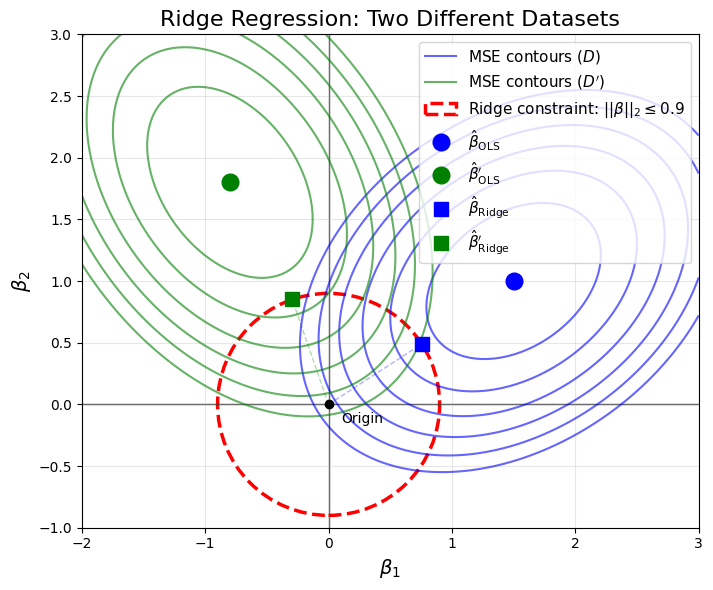

Dataset 1 - OLS estimate: β₁=1.500, β₂=1.000
Dataset 1 - Ridge estimate: β₁=0.755, β₂=0.490
Dataset 1 - Ridge constraint satisfied: ||β_ridge||₂ = 0.900 ≈ 0.9

Dataset 2 - OLS estimate: β₁=-0.800, β₂=1.800
Dataset 2 - Ridge estimate: β₁=-0.295, β₂=0.850
Dataset 2 - Ridge constraint satisfied: ||β_ridge||₂ = 0.900 ≈ 0.9


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.optimize import minimize_scalar

# Set up the figure
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Dataset 1: True OLS solution and covariance matrix
beta_ols1 = np.array([1.5, 1.0])
cov_matrix1 = np.array([[1.0, 0.3],
                         [0.3, 0.8]])
cov_inv1 = np.linalg.inv(cov_matrix1)

# Dataset 2: Different OLS solution and covariance matrix
beta_ols2 = np.array([-0.8, 1.8])
cov_matrix2 = np.array([[0.9, -0.4],
                         [-0.4, 1.2]])
cov_inv2 = np.linalg.inv(cov_matrix2)

# Create a grid for plotting contours
beta1_range = np.linspace(-2, 3, 200)
beta2_range = np.linspace(-1, 3, 200)
Beta1, Beta2 = np.meshgrid(beta1_range, beta2_range)

# Calculate MSE values for Dataset 1
MSE1 = np.zeros_like(Beta1)
for i in range(Beta1.shape[0]):
    for j in range(Beta1.shape[1]):
        beta = np.array([Beta1[i, j], Beta2[i, j]])
        diff = beta - beta_ols1
        MSE1[i, j] = diff @ cov_inv1 @ diff

# Calculate MSE values for Dataset 2
MSE2 = np.zeros_like(Beta1)
for i in range(Beta1.shape[0]):
    for j in range(Beta1.shape[1]):
        beta = np.array([Beta1[i, j], Beta2[i, j]])
        diff = beta - beta_ols2
        MSE2[i, j] = diff @ cov_inv2 @ diff

# Plot MSE contours for Dataset 1
contour_levels = [0.5, 1, 1.5, 2, 2.5, 3]
contours1 = ax.contour(Beta1, Beta2, MSE1, levels=contour_levels, colors='blue', alpha=0.6, linewidths=1.5)

# Plot MSE contours for Dataset 2
contours2 = ax.contour(Beta1, Beta2, MSE2, levels=contour_levels, colors='green', alpha=0.6, linewidths=1.5)

# Add dummy lines for legend
ax.plot([], [], 'b-', alpha=0.6, linewidth=1.5, label='MSE contours ($D$)')
ax.plot([], [], 'g-', alpha=0.6, linewidth=1.5, label="MSE contours ($D'$)")

# Ridge constraint radius
ridge_radius = 0.9

# Plot the ridge constraint circle
circle = Circle((0, 0), ridge_radius, fill=False, edgecolor='red', linewidth=2.5,
                linestyle='--', label=f'Ridge constraint: $||\\beta||_2 \leq {ridge_radius}$')
ax.add_patch(circle)

# Find ridge solutions for both datasets
def get_beta_ridge(lam, cov_inv, beta_ols):
    ridge_matrix = cov_inv + lam * np.eye(2)
    beta_ridge = np.linalg.inv(ridge_matrix) @ cov_inv @ beta_ols
    return beta_ridge

def constraint_violation(lam, cov_inv, beta_ols):
    beta_ridge = get_beta_ridge(lam, cov_inv, beta_ols)
    return (np.linalg.norm(beta_ridge) - ridge_radius)**2

# Find optimal lambda for Dataset 1
result1 = minimize_scalar(lambda l: constraint_violation(l, cov_inv1, beta_ols1), bounds=(0, 10), method='bounded')
optimal_lambda1 = result1.x
beta_ridge1 = get_beta_ridge(optimal_lambda1, cov_inv1, beta_ols1)

# Find optimal lambda for Dataset 2
result2 = minimize_scalar(lambda l: constraint_violation(l, cov_inv2, beta_ols2), bounds=(0, 10), method='bounded')
optimal_lambda2 = result2.x
beta_ridge2 = get_beta_ridge(optimal_lambda2, cov_inv2, beta_ols2)

# Add darker axis lines at origin
ax.axhline(y=0, color='black', linewidth=1, alpha=0.7, zorder=1)
ax.axvline(x=0, color='black', linewidth=1, alpha=0.7, zorder=1)

# Plot the OLS solutions
ax.plot(beta_ols1[0], beta_ols1[1], 'bo', markersize=12, label=r'$\hat \beta_\mathrm{OLS}$', zorder=5)
ax.plot(beta_ols2[0], beta_ols2[1], 'go', markersize=12, label=r"$\hat \beta_\mathrm{OLS}'$", zorder=5)

# Plot the ridge solutions
ax.plot(beta_ridge1[0], beta_ridge1[1], 'bs', markersize=10, label=r'$\hat \beta_\mathrm{Ridge}$', zorder=5)
ax.plot(beta_ridge2[0], beta_ridge2[1], 'gs', markersize=10, label=r"$\hat \beta_\mathrm{Ridge}'$", zorder=5)

# Draw lines from origin to ridge solutions
ax.plot([0, beta_ridge1[0]], [0, beta_ridge1[1]], 'b--', alpha=0.3, linewidth=1)
ax.plot([0, beta_ridge2[0]], [0, beta_ridge2[1]], 'g--', alpha=0.3, linewidth=1)

# Labels and formatting
ax.set_xlabel(r'$\beta_1$', fontsize=14)
ax.set_ylabel(r'$\beta_2$', fontsize=14)
ax.set_title('Ridge Regression: Two Different Datasets', fontsize=16)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=11)

# Set axis limits
ax.set_xlim(-2, 3)
ax.set_ylim(-1, 3)

# Add origin point
ax.plot(0, 0, 'ko', markersize=6, zorder=4)
ax.text(0.1, -0.15, 'Origin', fontsize=10)

plt.tight_layout()
plt.show()
fig.savefig("../figures/ridge_two_datasets.svg")

print(f"Dataset 1 - OLS estimate: β₁={beta_ols1[0]:.3f}, β₂={beta_ols1[1]:.3f}")
print(f"Dataset 1 - Ridge estimate: β₁={beta_ridge1[0]:.3f}, β₂={beta_ridge1[1]:.3f}")
print(f"Dataset 1 - Ridge constraint satisfied: ||β_ridge||₂ = {np.linalg.norm(beta_ridge1):.3f} ≈ {ridge_radius}")
print()
print(f"Dataset 2 - OLS estimate: β₁={beta_ols2[0]:.3f}, β₂={beta_ols2[1]:.3f}")
print(f"Dataset 2 - Ridge estimate: β₁={beta_ridge2[0]:.3f}, β₂={beta_ridge2[1]:.3f}")
print(f"Dataset 2 - Ridge constraint satisfied: ||β_ridge||₂ = {np.linalg.norm(beta_ridge2):.3f} ≈ {ridge_radius}")

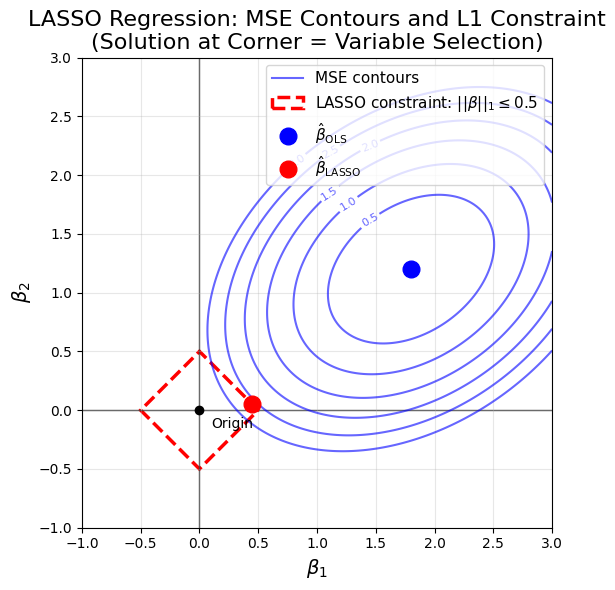

OLS estimate: β₁=1.800, β₂=1.200
LASSO estimate: β₁=0.446, β₂=0.054
LASSO constraint satisfied: ||β_lasso||₁ = 0.500 ≈ 0.5
LASSO solution is on an edge (both coefficients non-zero)

This demonstrates how LASSO encourages sparsity by setting coefficients to exactly zero!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.optimize import minimize

# Set up the figure
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Define the true OLS solution (ERM estimate)
# Positioning it so that LASSO solution will be at a corner
beta_ols = np.array([1.8, 1.2])

# Define the covariance matrix for the MSE ellipses
# This controls the shape of the MSE contours
cov_matrix = np.array([[1.0, 0.3],
                       [0.3, 0.8]])
cov_inv = np.linalg.inv(cov_matrix)

# Create a grid for plotting contours
beta1_range = np.linspace(-1, 3, 200)
beta2_range = np.linspace(-1, 3, 200)
Beta1, Beta2 = np.meshgrid(beta1_range, beta2_range)

# Calculate MSE values for the grid (quadratic form)
# MSE = (beta - beta_ols)^T * cov_inv * (beta - beta_ols)
MSE = np.zeros_like(Beta1)
for i in range(Beta1.shape[0]):
    for j in range(Beta1.shape[1]):
        beta = np.array([Beta1[i, j], Beta2[i, j]])
        diff = beta - beta_ols
        MSE[i, j] = diff @ cov_inv @ diff

# Plot MSE contours (limited to 3.0)
contour_levels = [0.5, 1, 1.5, 2, 2.5, 3]
contours = ax.contour(Beta1, Beta2, MSE, levels=contour_levels, colors='blue', alpha=0.6, linewidths=1.5)
ax.clabel(contours, inline=True, fontsize=8, fmt='%.1f')

# Add a dummy line for the legend to represent MSE contours
ax.plot([], [], 'b-', alpha=0.6, linewidth=1.5, label='MSE contours')

# LASSO constraint parameter (L1 radius) - smaller to force corner solution
lasso_radius = 0.5

# Plot the LASSO constraint diamond (L1 ball)
diamond_vertices = np.array([
    [lasso_radius, 0],    # Right vertex
    [0, lasso_radius],    # Top vertex
    [-lasso_radius, 0],   # Left vertex
    [0, -lasso_radius]    # Bottom vertex
])
diamond = Polygon(diamond_vertices, fill=False, edgecolor='red', linewidth=2.5,
                  linestyle='--', label=f'LASSO constraint: $||\\beta||_1 \\leq {lasso_radius}$')
ax.add_patch(diamond)

# Find the LASSO solution by checking all points on the L1 ball boundary
# The boundary consists of 4 line segments (edges of the diamond)

def mse_objective(beta):
    diff = beta - beta_ols
    return diff @ cov_inv @ diff

# Parameterize each edge of the diamond and find the minimum MSE along each edge
def minimize_on_edge(edge_func, param_range):
    """Minimize MSE along a parameterized edge of the diamond."""
    best_mse = np.inf
    best_beta = None
    for t in param_range:
        beta = edge_func(t)
        mse = mse_objective(beta)
        if mse < best_mse:
            best_mse = mse
            best_beta = beta
    return best_beta, best_mse

# Fine parameter grid for checking along each edge
t_grid = np.linspace(0, 1, 1000)

# Define the four edges of the diamond
# Edge 1: from (lasso_radius, 0) to (0, lasso_radius)
edge1 = lambda t: np.array([lasso_radius * (1 - t), lasso_radius * t])
# Edge 2: from (0, lasso_radius) to (-lasso_radius, 0)
edge2 = lambda t: np.array([lasso_radius * (-t), lasso_radius * (1 - t)])
# Edge 3: from (-lasso_radius, 0) to (0, -lasso_radius)
edge3 = lambda t: np.array([lasso_radius * (t - 1), lasso_radius * (-t)])
# Edge 4: from (0, -lasso_radius) to (lasso_radius, 0)
edge4 = lambda t: np.array([lasso_radius * t, lasso_radius * (t - 1)])

# Find the best solution along each edge
edges = [edge1, edge2, edge3, edge4]
candidates = [minimize_on_edge(edge, t_grid) for edge in edges]

# Select the best overall solution
best_idx = np.argmin([mse for _, mse in candidates])
beta_lasso, _ = candidates[best_idx]

# Add darker axis lines at origin
ax.axhline(y=0, color='black', linewidth=1, alpha=0.7, zorder=1)
ax.axvline(x=0, color='black', linewidth=1, alpha=0.7, zorder=1)

# Plot the OLS (ERM) solution
ax.plot(beta_ols[0], beta_ols[1], 'bo', markersize=12, label=r'$\hat \beta_\mathrm{OLS}$', zorder=5)

# Plot the LASSO solution
ax.plot(beta_lasso[0], beta_lasso[1], 'ro', markersize=12, label=r'$\hat \beta_\mathrm{LASSO}$', zorder=5)

# Highlight which coefficient was set to zero
if abs(beta_lasso[0]) < 1e-6:
    ax.annotate('β₁ = 0', xy=(beta_lasso[0], beta_lasso[1]), xytext=(0.2, beta_lasso[1] + 0.2),
                arrowprops=dict(arrowstyle='->', color='red'), fontsize=12, color='red')
elif abs(beta_lasso[1]) < 1e-6:
    ax.annotate('β₂ = 0', xy=(beta_lasso[0], beta_lasso[1]), xytext=(beta_lasso[0] + 0.2, 0.2),
                arrowprops=dict(arrowstyle='->', color='red'), fontsize=12, color='red')

# Labels and formatting
ax.set_xlabel(r'$\beta_1$', fontsize=14)
ax.set_ylabel(r'$\beta_2$', fontsize=14)
ax.set_title('LASSO Regression: MSE Contours and L1 Constraint\n(Solution at Corner = Variable Selection)', fontsize=16)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=11)

# Set axis limits
ax.set_xlim(-1, 3)
ax.set_ylim(-1, 3)

# Add origin point
ax.plot(0, 0, 'ko', markersize=6, zorder=4)
ax.text(0.1, -0.15, 'Origin', fontsize=10)

plt.tight_layout()
plt.show()
fig.savefig("../figures/lasso.svg")

print(f"OLS estimate: β₁={beta_ols[0]:.3f}, β₂={beta_ols[1]:.3f}")
print(f"LASSO estimate: β₁={beta_lasso[0]:.3f}, β₂={beta_lasso[1]:.3f}")
print(f"LASSO constraint satisfied: ||β_lasso||₁ = {np.sum(np.abs(beta_lasso)):.3f} ≈ {lasso_radius}")

# Determine which coefficient was set to zero
if abs(beta_lasso[0]) < 1e-6:
    print("LASSO performed variable selection: β₁ was set to exactly 0")
elif abs(beta_lasso[1]) < 1e-6:
    print("LASSO performed variable selection: β₂ was set to exactly 0")
else:
    print("LASSO solution is on an edge (both coefficients non-zero)")

print("\nThis demonstrates how LASSO encourages sparsity by setting coefficients to exactly zero!")

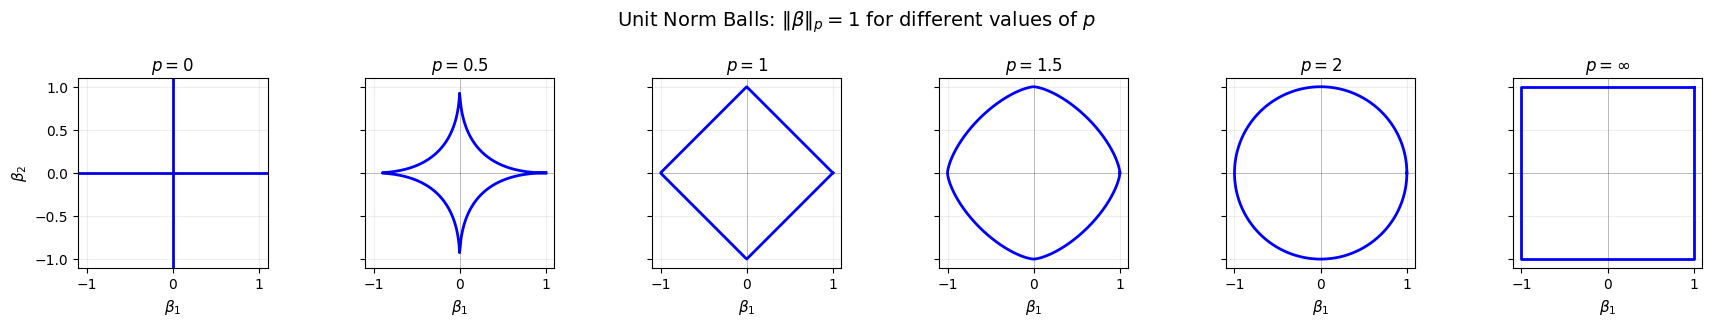

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Set up the figure with 1x6 subplots
fig, axes = plt.subplots(1, 6, figsize=(18, 3), sharex=True, sharey=True)

# Define the p values to plot
p_values = [0, 0.5, 1, 1.5, 2, 100]

# Function to compute the unit norm ball boundary for a given p
def unit_norm_ball(p, num_points=1000):
    """Compute points on the boundary of the unit Lp norm ball in 2D."""
    if p == 0:
        # L0 "norm" - just the corners
        return np.array([[1, 0], [0, 1], [-1, 0], [0, -1], [1, 0]]).T
    elif p == np.inf:
        # L∞ norm - square
        return np.array([[1, 1], [-1, 1], [-1, -1], [1, -1], [1, 1]]).T
    else:
        # For other p values, sample angles and compute radius
        theta = np.linspace(0, 2*np.pi, num_points)

        # For Lp norm: (|x|^p + |y|^p)^(1/p) = 1
        # In polar-like form: x = r*cos(θ), y = r*sin(θ)
        # We need: (|r*cos(θ)|^p + |r*sin(θ)|^p)^(1/p) = 1
        # So: r = 1 / (|cos(θ)|^p + |sin(θ)|^p)^(1/p)

        cos_theta = np.cos(theta)
        sin_theta = np.sin(theta)

        # Compute radius for each angle
        r = 1.0 / (np.abs(cos_theta)**p + np.abs(sin_theta)**p)**(1.0/p)

        x = r * cos_theta
        y = r * sin_theta

        return x, y

# Plot each p value
for idx, (ax, p) in enumerate(zip(axes, p_values)):
    if p == 0:
        # Special case for p=0 (not really a norm, but show the corners)
        ax.axhline(0, color="blue", linewidth=2)
        ax.axvline(0, color="blue", linewidth=2)
        p_display = 0
    elif p >= 100:
        # Treat as L∞
        x, y = unit_norm_ball(np.inf)
        ax.plot(x, y, 'b-', linewidth=2)
        p_display = r'\infty'
    else:
        x, y = unit_norm_ball(p)
        ax.plot(x, y, 'b-', linewidth=2)
        p_display = p

    # Formatting
    ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='black', linewidth=0.5, alpha=0.3)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_title(f'$p = {p_display}$', fontsize=12)

    # Only show y-axis label on first subplot
    if idx == 0:
        ax.set_ylabel(r'$\beta_2$', fontsize=11)

    # Show x-axis label on all
    ax.set_xlabel(r'$\beta_1$', fontsize=11)

fig.suptitle(r'Unit Norm Balls: $\|\beta\|_p = 1$ for different values of $p$', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig("../figures/norm_balls.svg")